<a href="https://colab.research.google.com/github/Darwisher/BigDataGroupProject/blob/main/Bigdataproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Then update your file path to point to where it lives in your Drive:
file_path = '/content/drive/MyDrive/Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

# 1. Loading Data in chunks and filtering crops
chunk_size = 500000
chunks = []
target_crops = ['Wheat', 'Maize', 'Rice']
pattern = '|'.join(target_crops)

print("Starting to read and filter 1.7GB Dataset... this may take a moment.")
for chunk in pd.read_csv('/content/drive/MyDrive/Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv', chunksize=chunk_size, encoding='latin1'):
    mask = chunk['Item'].str.contains(pattern, case=False, na=False)
    chunks.append(chunk[mask])

df_raw = pd.concat(chunks, ignore_index=True)
print("Filtering complete. Rows retrieved:", df_raw.shape[0])

# 2. Filtering Irrelevant Columns
print("Cleaning Data...")
cols_to_drop = ['Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code']
df_clean = df_raw.drop(columns=[col for col in cols_to_drop if col in df_raw.columns])

# 3. Reshaping Data
year_cols = [col for col in df_clean.columns if col.startswith('Y') and col[1:].isdigit()]
id_cols = [col for col in df_clean.columns if col not in year_cols]

df_melted = pd.melt(df_clean, id_vars=id_cols, value_vars=year_cols, var_name='Year', value_name='Value')

# 4. Final Processing
df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)
df_melted = df_melted.dropna(subset=['Value'])
df_melted = df_melted.drop_duplicates()
df_melted = df_melted[df_melted['Value'] >= 0]

# 5. Save Preprocessed dataset
output_file = 'Preprocessed_Trade_Data.csv'
df_melted.to_csv(output_file, index=False)
print(f"Preprocessed dataset saved successfully to {output_file}!")


Starting to read and filter 1.7GB Dataset... this may take a moment.
Filtering complete. Rows retrieved: 326172
Cleaning Data...
Preprocessed dataset saved successfully to Preprocessed_Trade_Data.csv!


In [3]:
import csv
import re

#  Fixed - full Drive paths
input_file  = '/content/drive/MyDrive/Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'
output_file = '/content/drive/MyDrive/Preprocessed_Trade_Data.csv'

# Drops
cols_to_drop = {'Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code'}

target_crops = ['Wheat', 'Maize', 'Rice']

def contains_target(item_str):
    item_lower = item_str.lower()
    for crop in target_crops:
        if crop.lower() in item_lower:
            return True
    return False

print("Processing massively large CSV row by row. This uses almost NO Memory (Pure Python).")

with open(input_file, mode='r', encoding='latin1') as infile, \
     open(output_file, mode='w', encoding='utf-8', newline='') as outfile:

    reader = csv.reader(infile)
    writer = csv.writer(outfile)

    # Read Header
    header = next(reader)

    # Analyze Header
    year_indices = []
    keep_indices = []
    item_idx = -1

    out_header = []

    for i, col in enumerate(header):
        if col == 'Item':
            item_idx = i

        if col.startswith('Y') and col[1:].isdigit():
            year_indices.append((i, col[1:])) # Ex: 'Y1986' -> '1986'
        elif col not in cols_to_drop:
            keep_indices.append(i)
            out_header.append(col)

    out_header.extend(['Year', 'Value'])
    writer.writerow(out_header)

    # Stream rows
    rows_processed = 0
    rows_written = 0
    seen = set() # To handle drop_duplicates

    for row in reader:
        rows_processed += 1
        if rows_processed % 1000000 == 0:
            print(f"Processed {rows_processed} rows...")

        # If pattern matches
        if len(row) > item_idx and contains_target(row[item_idx]):
            # Base info
            base_data = tuple(row[i] for i in keep_indices)

            # Melt Years
            for y_idx, year_val in year_indices:
                if y_idx < len(row):
                    val = row[y_idx]
                    # Drop Missing values and keep >= 0
                    if val.strip() != '':
                        try:
                            # Parse numeric
                            numeric_val = float(val)
                            if numeric_val >= 0:
                                # Create row fingerprint
                                out_row = base_data + (year_val, numeric_val)
                                if out_row not in seen:
                                    seen.add(out_row)
                                    writer.writerow(out_row)
                                    rows_written += 1
                        except ValueError:
                            pass # Ignored invalid values

print(f"Finished! Total Rows Scanned: {rows_processed}")
print(f"Total Rows Saved to Preprocessed Dataset: {rows_written}")
print(f"Saved directly to -> '{output_file}'")


Processing massively large CSV row by row. This uses almost NO Memory (Pure Python).
Processed 1000000 rows...
Processed 2000000 rows...
Processed 3000000 rows...
Processed 4000000 rows...
Processed 5000000 rows...
Processed 6000000 rows...
Finished! Total Rows Scanned: 6640547
Total Rows Saved to Preprocessed Dataset: 2437186
Saved directly to -> '/content/drive/MyDrive/Preprocessed_Trade_Data.csv'


In [4]:
 #1. Dataset Gathering

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style='darkgrid')

In [6]:
import pandas as pd

#2. Loading and Pre-Processing (Raw Data EDA)
chunk_size = 500000
chunks = []
target_crops = ['Wheat', 'Maize', 'Rice']

# Define the file path
file_path = '/content/drive/MyDrive/Trade_DetailedTradeMatrix_E_All_Data_NOFLAG.csv'  # ✅

# Use regex to find elements containing our target crops
pattern = '|'.join(target_crops)

print("Loading large Data into Memory via chunks...")
for chunk in pd.read_csv(file_path, chunksize=chunk_size, encoding='latin1'):
    mask = chunk['Item'].str.contains(pattern, case=False, na=False)
    chunks.append(chunk[mask])

df_raw = pd.concat(chunks, ignore_index=True)
print('Raw Filtered Data Shape:', df_raw.shape)
df_raw.head()

Loading large Data into Memory via chunks...
Raw Filtered Data Shape: (326172, 51)


,Reporter Country Code,Reporter Country Code (M49),Reporter Countries,Partner Country Code,Partner Country Code (M49),Partner Countries,Item Code,Item Code (CPC),Item,Element Code,...,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Y2021,Y2022,Y2023,Y2024
0,2,'004,Afghanistan,10,'036,Australia,31,'23161.02,"Rice, milled",5610,...,NaN,NaN,69.08,NaN,54.95,NaN,NaN,NaN,NaN,NaN
1,2,'004,Afghanistan,10,'036,Australia,31,'23161.02,"Rice, milled",5622,...,NaN,NaN,32.00,NaN,47.00,NaN,NaN,NaN,NaN,NaN
2,2,'004,Afghanistan,10,'036,Australia,30,'F0030,"Rice, paddy (rice milled equivalent)",5610,...,NaN,NaN,69.08,NaN,54.95,NaN,NaN,NaN,NaN,NaN
3,2,'004,Afghanistan,10,'036,Australia,30,'F0030,"Rice, paddy (rice milled equivalent)",5622,...,NaN,NaN,32.00,NaN,47.00,NaN,NaN,NaN,NaN,NaN
4,2,'004,Afghanistan,52,'031,Azerbaijan,15,'0111,Wheat,5610,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ### Pre-processing Exploratory Data Analysis (EDA)
# Display column info and data types
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 326172 entries, 0 to 326171
Data columns (total 51 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Reporter Country Code        326172 non-null  int64  
 1   Reporter Country Code (M49)  326172 non-null  object 
 2   Reporter Countries           326172 non-null  object 
 3   Partner Country Code         326172 non-null  int64  
 4   Partner Country Code (M49)   326172 non-null  object 
 5   Partner Countries            326172 non-null  object 
 6   Item Code                    326172 non-null  int64  
 7   Item Code (CPC)              326172 non-null  object 
 8   Item                         326172 non-null  object 
 9   Element Code                 326172 non-null  int64  
 10  Element                      326172 non-null  object 
 11  Unit                         326172 non-null  object 
 12  Y1986                        17464 non-null   float64
 13 

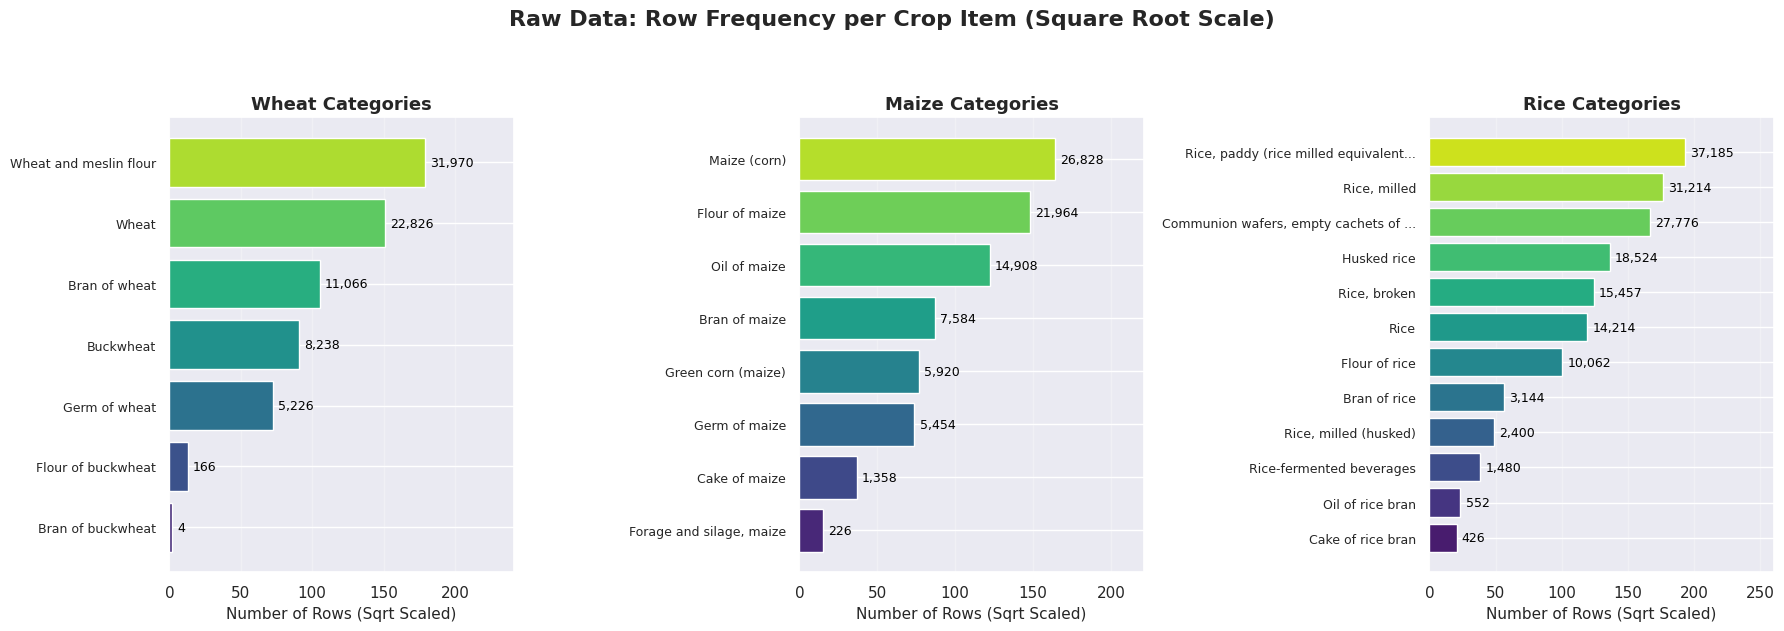

In [8]:
# --- Pre-Cleaning: Raw Crop Frequency Distribution (Square Root Scale) ---
# Count how many rows exist per crop item in the raw wide-format data
crop_counts = df_raw['Item'].value_counts().reset_index()
crop_counts.columns = ['Item', 'Count']

# 1. Clean up category names by TRUNCATING instead of wrapping
# This keeps it on one line so they don't overlap vertically
crop_counts['Short_Item'] = crop_counts['Item'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x
)

# 2. Assign main categories for splitting
def assign_category(item):
    item_lower = item.lower()
    if 'wheat' in item_lower: return 'Wheat'
    elif 'maize' in item_lower or 'corn' in item_lower: return 'Maize'
    elif 'rice' in item_lower: return 'Rice'
    return 'Other'

crop_counts['Category'] = crop_counts['Item'].apply(assign_category)

# 3. Plotting separated horizontal bar charts
categories = ['Wheat', 'Maize', 'Rice']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)
fig.suptitle('Raw Data: Row Frequency per Crop Item (Square Root Scale)', fontsize=16, fontweight='bold', y=1.05)

for ax, cat in zip(axes, categories):
    # Get data for this category and sort ascending for horizontal bar chart
    cat_data = crop_counts[crop_counts['Category'] == cat].sort_values('Count', ascending=True)

    # Apply square root scaling for the bar lengths
    y_pos = np.arange(len(cat_data))
    plot_values = np.sqrt(cat_data['Count'])

    bars = ax.barh(y_pos, plot_values, color=sns.color_palette('viridis', len(cat_data)))

    # Set y-ticks to the truncated item names
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cat_data['Short_Item'], fontsize=9)

    # Annotate bars with the EXACT original counts
    for i, bar in enumerate(bars):
        actual_count = cat_data.iloc[i]['Count']
        ax.text(
            bar.get_width() + (plot_values.max() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{actual_count:,}',
            va='center', ha='left', fontsize=9, color='black'
        )

    ax.set_title(f'{cat} Categories', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Rows (Sqrt Scaled)', fontsize=11)

    # Extend x-axis limit slightly to make room for text labels
    ax.set_xlim(0, plot_values.max() * 1.35)
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# ## 3. Data Cleaning and Processing
# 1. Filter irrelevant columns
cols_to_drop = ['Reporter Country Code', 'Reporter Country Code (M49)',
                'Partner Country Code', 'Partner Country Code (M49)',
                'Item Code', 'Item Code (CPC)', 'Element Code']
df_clean = df_raw.drop(columns=[col for col in cols_to_drop if col in df_raw.columns])

# 2. Reshape: Wide to Long format
year_cols = [col for col in df_clean.columns if col.startswith('Y') and col[1:].isdigit()]
id_cols = [col for col in df_clean.columns if col not in year_cols]

df_melted = pd.melt(df_clean, id_vars=id_cols, value_vars=year_cols, var_name='Year', value_name='Value')

# Convert 'Year' to integer instead of 'Y1986'
df_melted['Year'] = df_melted['Year'].str.replace('Y', '').astype(int)

# 3. Handle Missing Values (Drop rows where Value is missing as it means no trade occurred)
df_melted = df_melted.dropna(subset=['Value'])

# 4. Remove Duplicates
df_melted = df_melted.drop_duplicates()

# Optional: Quick check for any impossible negative physical quantities/values
df_melted = df_melted[df_melted['Value'] >= 0]

print("Cleaned and Melted Data Shape:", df_melted.shape)
df_melted.head()

Cleaned and Melted Data Shape: (2437186, 7)


,Reporter Countries,Partner Countries,Item,Element,Unit,Year,Value
1248,Algeria,Albania,Wheat and meslin flour,Import quantity,t,1986,1200.0
1249,Algeria,Albania,Wheat and meslin flour,Import value,1000 USD,1986,266.0
1254,Algeria,Argentina,Maize (corn),Import quantity,t,1986,358269.0
1255,Algeria,Argentina,Maize (corn),Import value,1000 USD,1986,46565.0
1346,Algeria,Canada,Wheat,Import quantity,t,1986,389118.0


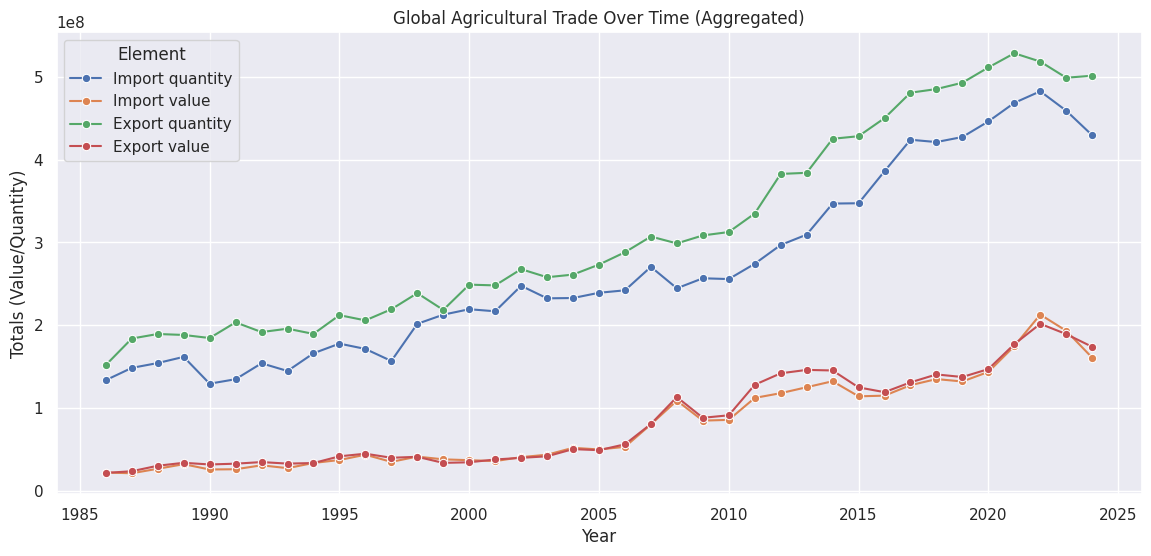

In [10]:
# ## 4. Post-Preprocessing EDA
# 1. Trade Value Trends Over Time
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_melted, x='Year', y='Value', hue='Element', estimator=sum, errorbar=None, marker="o")
plt.title('Global Agricultural Trade Over Time (Aggregated)')
plt.ylabel('Totals (Value/Quantity)')
plt.xlabel('Year')
plt.show()

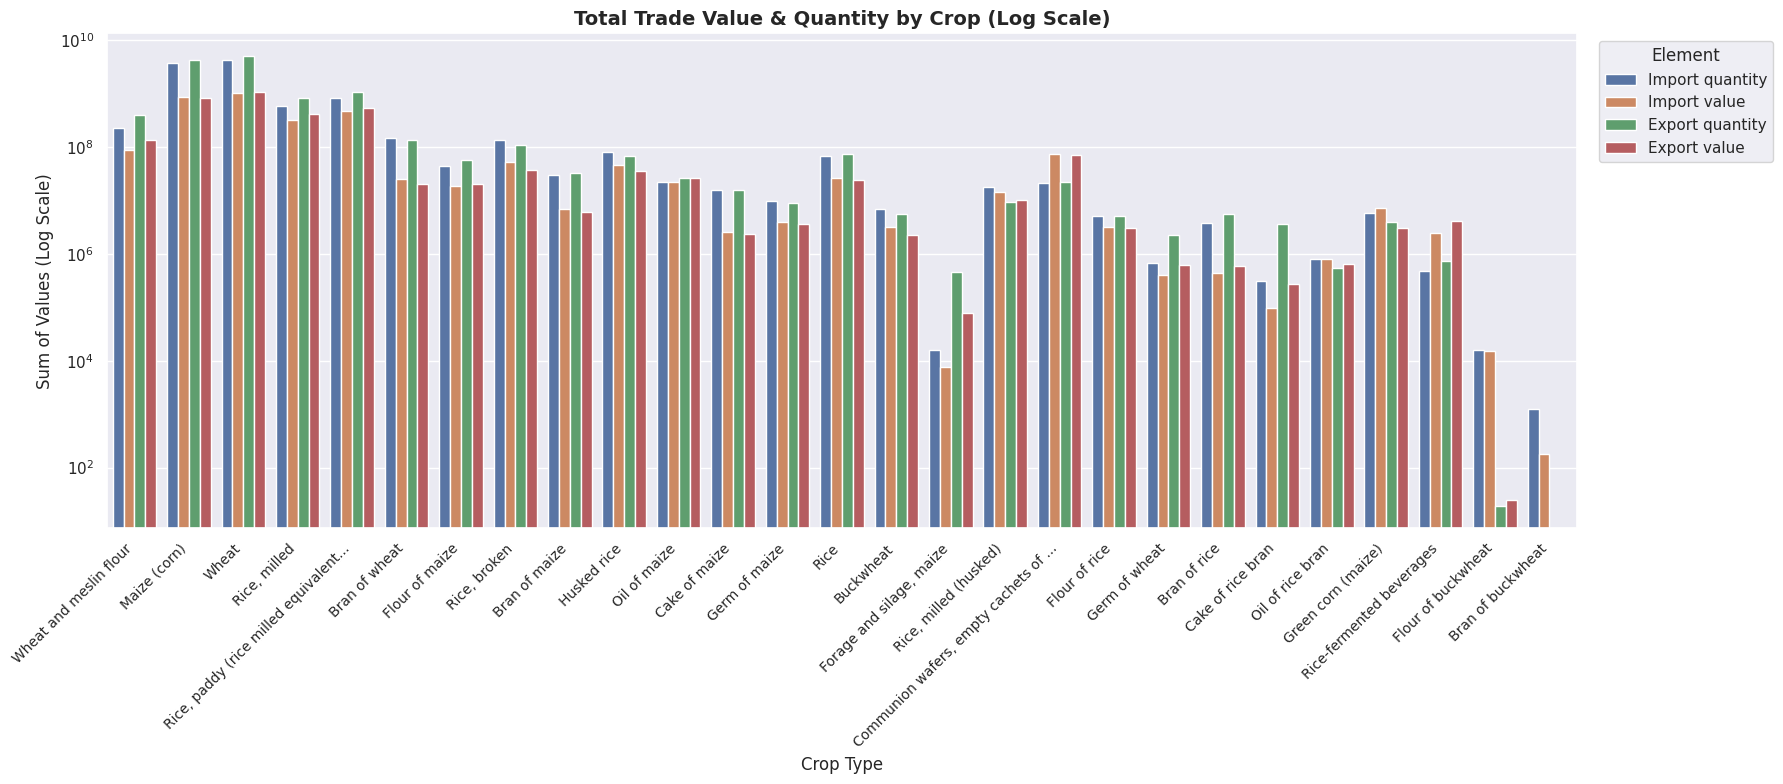

In [11]:
# --- Distribution by Crop — Log Y-Axis ---
# 1. Create a temporary column with the exact same truncation logic
df_melted['Short_Item'] = df_melted['Item'].apply(
    lambda x: x[:35] + '...' if len(x) > 35 else x
)

plt.figure(figsize=(18, 8))
sns.barplot(
    data=df_melted,
    x='Short_Item', y='Value',  # Use the truncated names
    hue='Element',
    estimator=sum,
    errorbar=None
)

plt.yscale('log')  # Log scale keeps minor sub-categories visible
plt.title('Total Trade Value & Quantity by Crop (Log Scale)', fontsize=14, fontweight='bold')
plt.ylabel('Sum of Values (Log Scale)', fontsize=12)
plt.xlabel('Crop Type', fontsize=12)

# Rotate 45 degrees, and the shortened names will fit perfectly without pushing the chart up
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(title='Element', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Drop the temporary column so it doesn't affect the rest of your notebook
df_melted.drop(columns=['Short_Item'], inplace=True)

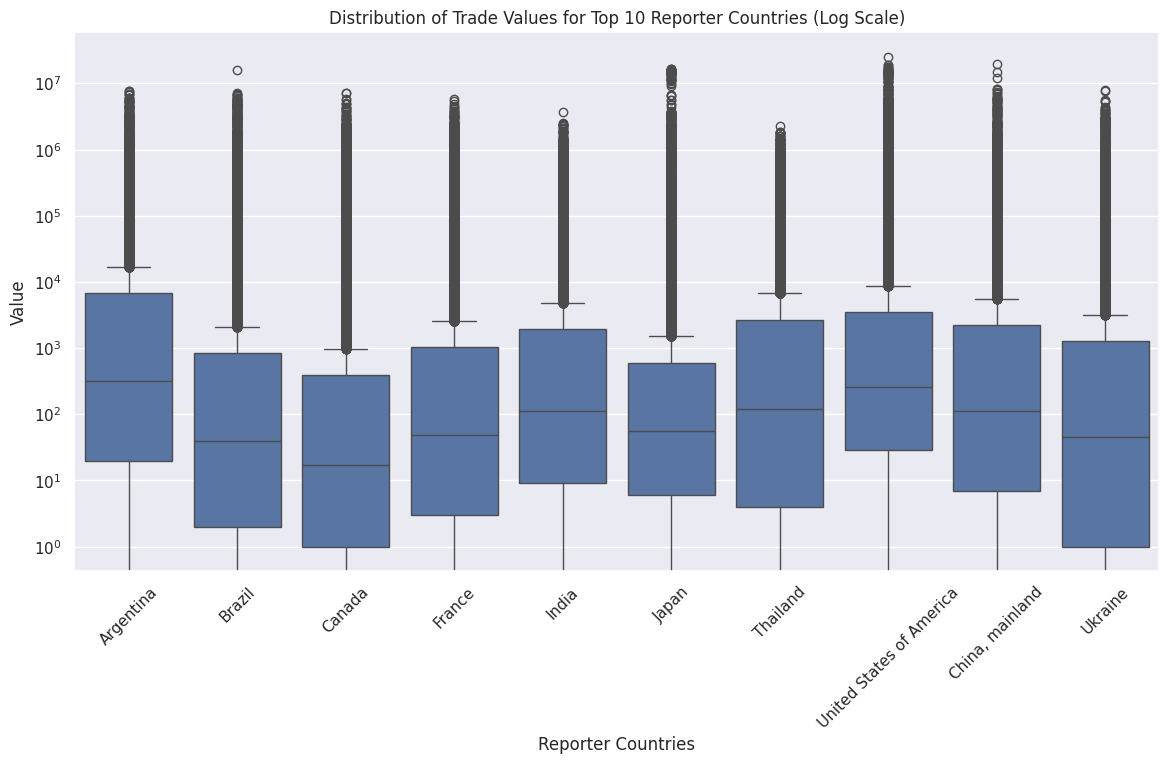

In [12]:
# 3. Filter top 10 Reporter Countries by volume to see who exports/imports the most
top_reporters = df_melted.groupby('Reporter Countries')['Value'].sum().sort_values(ascending=False).head(10).index
df_top_reporters = df_melted[df_melted['Reporter Countries'].isin(top_reporters)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_reporters, x='Reporter Countries', y='Value')
plt.yscale('log') # Log scale due to large outliers
plt.title('Distribution of Trade Values for Top 10 Reporter Countries (Log Scale)')
plt.xticks(rotation=45)
plt.show()

In [13]:
# ## 5. Exporting Preprocessed Data

In [14]:
df_melted.to_csv('Preprocessed_Trade_Data.csv', index=False)
print("Successfully saved -> 'Preprocessed_Trade_Data.csv'")

Successfully saved -> 'Preprocessed_Trade_Data.csv'


---
# Week 3: Baseline Model Development
### Group: MCJR | Topic: Global Agricultural Trends and Top Food Exporters

**Objective 1 → Outlier/Disruption Detection:** Random Forest Regressor  
**Objective 2 → 5-Year Export Forecasting:** Linear Regression  

| Member | Task |
|--------|------|
| Charles  | Data preparation & feature engineering for ML |
| Jeffrey  | Linear Regression — baseline model & forecasting |
| Mark     | Random Forest — outlier/disruption detection |
| Rajvir   | Model evaluation, comparison & forecast visualizations |
---


In [15]:
# =============================================
# WEEK 3 — ADDITIONAL IMPORTS FOR MODELING
# =============================================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.patches as mpatches

print(" Week 3 modeling libraries loaded.")


 Week 3 modeling libraries loaded.


In [16]:
# =============================================
# TASK — Charles: DATA PREPARATION FOR MODELING
# Filter df_melted to Export Quantity records only,
# simplify crop labels, encode categoricals
# =============================================

# --- Step 1: Filter to Export Quantity only ---
df_exports = df_melted[
    df_melted['Element'].str.contains('Export Quantity', case=False, na=False)
].copy()

print(f"Export Quantity records: {len(df_exports):,}")
print(f"Elements present after filter: {df_exports['Element'].unique()}")

# --- Step 2: Simplify crop names (variants → 3 canonical labels) ---
def simplify_crop(item):
    item_lower = item.lower()
    if 'wheat' in item_lower:
        return 'Wheat'
    elif 'maize' in item_lower or 'corn' in item_lower:
        return 'Maize'
    elif 'rice' in item_lower:
        return 'Rice'
    return 'Other'

df_exports['Crop'] = df_exports['Item'].apply(simplify_crop)
df_exports = df_exports[df_exports['Crop'] != 'Other']

# --- Step 3: Aggregate (sum bilateral trade per country-crop-year) ---
# The FAO matrix is bilateral (reporter-partner pairs), so we group
# by Reporter Countries + Crop + Year to get total exports per country
df_exports_agg = df_exports.groupby(
    ['Reporter Countries', 'Crop', 'Year'], as_index=False
)['Value'].sum()

print(f"\n Aggregated shape: {df_exports_agg.shape}")
print(f"   Year range : {df_exports_agg['Year'].min()} – {df_exports_agg['Year'].max()}")
print(f"   Crops      : {df_exports_agg['Crop'].unique()}")
print(f"   Countries  : {df_exports_agg['Reporter Countries'].nunique()} unique")
df_exports_agg.head(10)


Export Quantity records: 601,282
Elements present after filter: ['Export quantity']

 Aggregated shape: (12493, 4)
   Year range : 1986 – 2024
   Crops      : ['Maize' 'Rice' 'Wheat']
   Countries  : 191 unique


,Reporter Countries,Crop,Year,Value
0,Afghanistan,Maize,2009,73.00
1,Afghanistan,Maize,2010,45.00
2,Afghanistan,Rice,2019,13106.16
3,Albania,Maize,1996,168.00
4,Albania,Maize,1997,32.00
5,Albania,Maize,1999,11.00
6,Albania,Maize,2004,186.00
7,Albania,Maize,2005,52.00
8,Albania,Maize,2006,95.00
9,Albania,Maize,2007,427.00


In [17]:
# =============================================
# TASK — Charles: FEATURE ENGINEERING & SPLIT
# =============================================

# --- Encode categorical columns ---
le_country = LabelEncoder()
le_crop    = LabelEncoder()

df_exports_agg['Country_encoded'] = le_country.fit_transform(df_exports_agg['Reporter Countries'])
df_exports_agg['Crop_encoded']    = le_crop.fit_transform(df_exports_agg['Crop'])

# --- Features and Target ---
# X: Year, Country (encoded), Crop (encoded)
# y: Export Quantity (1000 tonnes)
feature_cols = ['Year', 'Country_encoded', 'Crop_encoded']
X = df_exports_agg[feature_cols].values
y = df_exports_agg['Value'].values

# --- Temporal train/test split ---
# Train: 1986–2017 | Test: 2018–2022 (realistic holdout)
train_mask = df_exports_agg['Year'] < 2018
test_mask  = df_exports_agg['Year'] >= 2018

X_train = df_exports_agg.loc[train_mask, feature_cols].values
X_test  = df_exports_agg.loc[test_mask,  feature_cols].values
y_train = df_exports_agg.loc[train_mask, 'Value'].values
y_test  = df_exports_agg.loc[test_mask,  'Value'].values

print(" Feature engineering & train/test split complete.")
print(f"   Features       : {feature_cols}")
print(f"   Training size  : {len(X_train):,} records (Years < 2018)")
print(f"   Test size      : {len(X_test):,} records (Years 2018–2022)")
print(f"   Feature matrix : {X.shape}")


 Feature engineering & train/test split complete.
   Features       : ['Year', 'Country_encoded', 'Crop_encoded']
   Training size  : 9,649 records (Years < 2018)
   Test size      : 2,844 records (Years 2018–2022)
   Feature matrix : (12493, 3)


In [18]:
# =============================================
# TASK — Jeffrey: LINEAR REGRESSION BASELINE
# Objective 2 — Forecasting export volumes
# =============================================

# --- Train ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- Predict on test set ---
y_pred_lr = lr_model.predict(X_test)

# --- Metrics ---
lr_r2   = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)

print("=" * 55)
print("📈 LINEAR REGRESSION — Baseline Model Results")
print("=" * 55)
print(f"  R² Score : {lr_r2:.4f}  (1.0 = perfect fit)")
print(f"  RMSE     : {lr_rmse:,.2f} (1000 tonnes)")
print(f"  MAE      : {lr_mae:,.2f}  (1000 tonnes)")
print()
print("  Model Coefficients:")
for fname, coef in zip(feature_cols, lr_model.coef_):
    print(f"    {fname:<20}: {coef:.4f}")
print(f"  Intercept: {lr_model.intercept_:.4f}")


📈 LINEAR REGRESSION — Baseline Model Results
  R² Score : -0.0010  (1.0 = perfect fit)
  RMSE     : 5,322,040.03 (1000 tonnes)
  MAE      : 1,836,761.80  (1000 tonnes)

  Model Coefficients:
    Year                : 6599.4353
    Country_encoded     : 4551.0284
    Crop_encoded        : 171870.0769
  Intercept: -12921924.1184


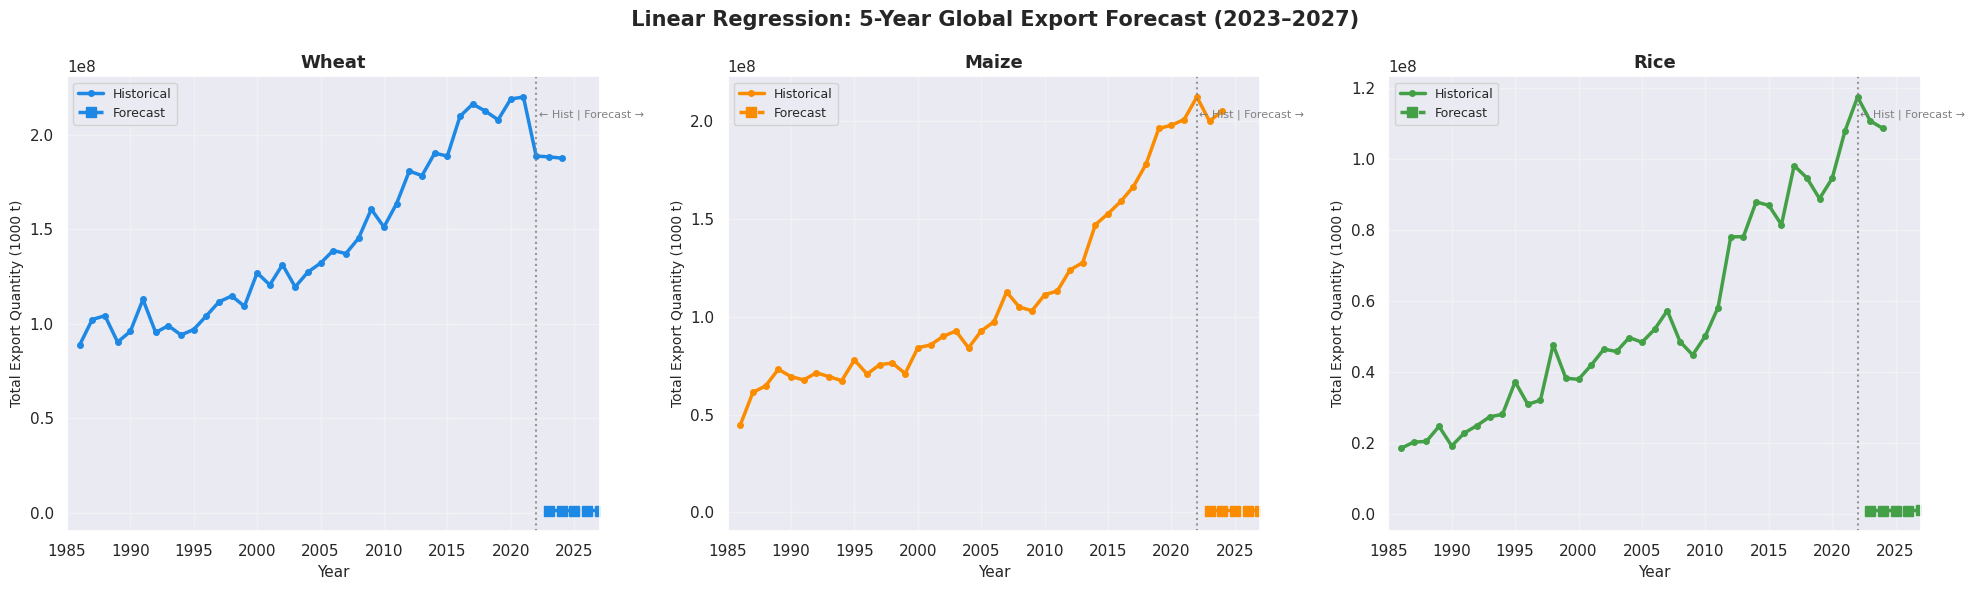


 5-Year Export Forecast Summary (1000 tonnes):
Crop      Maize        Rice       Wheat
Year                                   
2023  838326.14  1010196.22  1182066.29
2024  844925.58  1016795.65  1188665.73
2025  851525.01  1023395.09  1195265.16
2026  858124.45  1029994.52  1201864.60
2027  864723.88  1036593.96  1208464.04


In [19]:
# =============================================
# TASK — Jeffrey: 5-YEAR FORECAST (2023–2027)
# Using the trained Linear Regression model
# =============================================

future_years = np.arange(2023, 2028)
crop_list    = ['Wheat', 'Maize', 'Rice']
crop_colors  = ['#1E88E5', '#FB8C00', '#43A047']

forecast_records = []

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
fig.suptitle(' Linear Regression: 5-Year Global Export Forecast (2023–2027)',
             fontsize=15, fontweight='bold')

for ax, crop, color in zip(axes, crop_list, crop_colors):
    # Historical: aggregate across all countries per year
    hist = df_exports_agg[df_exports_agg['Crop'] == crop].groupby('Year')['Value'].sum().reset_index()

    # Build future input: use median country encoding across dataset
    crop_enc       = le_crop.transform([crop])[0]
    median_country = int(np.median(df_exports_agg['Country_encoded']))
    X_future       = np.array([[yr, median_country, crop_enc] for yr in future_years])
    y_future       = np.maximum(lr_model.predict(X_future), 0)  # No negative exports

    # Store forecast
    for yr, val in zip(future_years, y_future):
        forecast_records.append({'Crop': crop, 'Year': yr, 'Forecast (1000 t)': round(val, 2)})

    # Plot
    ax.plot(hist['Year'], hist['Value'],
            color=color, linewidth=2.5, marker='o', markersize=4, label='Historical')
    ax.plot(future_years, y_future,
            color=color, linewidth=2.5, linestyle='--', marker='s', markersize=7, label='Forecast')
    ax.axvline(x=2022, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.text(2022.2, hist['Value'].max() * 0.95, '← Hist | Forecast →', fontsize=8, color='gray')

    ax.set_title(crop, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Total Export Quantity (1000 t)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(df_exports_agg['Year'].min() - 1, 2027)

plt.tight_layout()
plt.savefig('lr_forecast_5year.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
forecast_df = pd.DataFrame(forecast_records)
pivot_table  = forecast_df.pivot(index='Year', columns='Crop', values='Forecast (1000 t)')
print("\n 5-Year Export Forecast Summary (1000 tonnes):")
print(pivot_table.to_string())


In [20]:
# =============================================
# TASK — Mark: RANDOM FOREST OUTLIER DETECTION
# Objective 1 — Detect trade disruptions
# Strategy: High residual (actual vs RF prediction)
# = statistically significant trade disruption
# =============================================

# --- Train Random Forest ---
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print(" Random Forest trained.")

# --- Predict across FULL dataset to detect outliers ---
X_all = df_exports_agg[feature_cols].values
y_all = df_exports_agg['Value'].values

df_exports_agg['RF_Predicted'] = rf_model.predict(X_all)
df_exports_agg['Residual']     = df_exports_agg['Value'] - df_exports_agg['RF_Predicted']
df_exports_agg['Abs_Residual'] = df_exports_agg['Residual'].abs()

# --- Flag outliers: residual > 2 standard deviations ---
std_residual = df_exports_agg['Residual'].std()
threshold    = 2 * std_residual
df_exports_agg['Is_Disruption'] = df_exports_agg['Abs_Residual'] > threshold

n_disruptions = df_exports_agg['Is_Disruption'].sum()
pct           = (n_disruptions / len(df_exports_agg)) * 100

# --- Test set evaluation ---
y_pred_rf_test = rf_model.predict(X_test)
rf_r2   = r2_score(y_test, y_pred_rf_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_mae  = mean_absolute_error(y_test, y_pred_rf_test)

print("=" * 60)
print(" RANDOM FOREST — Disruption Detection Results")
print("=" * 60)
print(f"  Records analyzed     : {len(df_exports_agg):,}")
print(f"  Residual Std Dev     : {std_residual:,.2f}")
print(f"  Outlier threshold    : ±{threshold:,.2f} (1000 tonnes)")
print(f"  Disruptions flagged  : {n_disruptions} ({pct:.1f}% of records)")
print()
print("  Random Forest Test Performance:")
print(f"    R² Score : {rf_r2:.4f}")
print(f"    RMSE     : {rf_rmse:,.2f} (1000 tonnes)")
print(f"    MAE      : {rf_mae:,.2f}  (1000 tonnes)")

print("\n Top 10 Detected Trade Disruptions:")
top_disruptions = (
    df_exports_agg[df_exports_agg['Is_Disruption']]
    .nlargest(10, 'Abs_Residual')
    [['Year', 'Reporter Countries', 'Crop', 'Value', 'RF_Predicted', 'Residual']]
    .reset_index(drop=True)
)
top_disruptions.columns = ['Year', 'Country', 'Crop', 'Actual (1000t)', 'RF Predicted', 'Residual']
print(top_disruptions.to_string(index=False))


 Random Forest trained.
 RANDOM FOREST — Disruption Detection Results
  Records analyzed     : 12,493
  Residual Std Dev     : 1,593,532.41
  Outlier threshold    : ±3,187,064.82 (1000 tonnes)
  Disruptions flagged  : 300 (2.4% of records)

  Random Forest Test Performance:
    R² Score : 0.7388
    RMSE     : 2,718,847.55 (1000 tonnes)
    MAE      : 752,049.25  (1000 tonnes)

 Top 10 Detected Trade Disruptions:
 Year                  Country  Crop  Actual (1000t)  RF Predicted     Residual
 2023                   Brazil Maize     56624778.88  7.175180e+06 4.944960e+07
 2022                   Brazil Maize     43777511.05  7.175180e+06 3.660233e+07
 2019                   Brazil Maize     42885869.85  7.175180e+06 3.571069e+07
 2024                   Brazil Maize     40676838.19  7.175180e+06 3.350166e+07
 2022                    India  Rice     44317456.00  1.471242e+07 2.960504e+07
 2018       Russian Federation Wheat     45102826.13  1.642567e+07 2.867716e+07
 2021                  

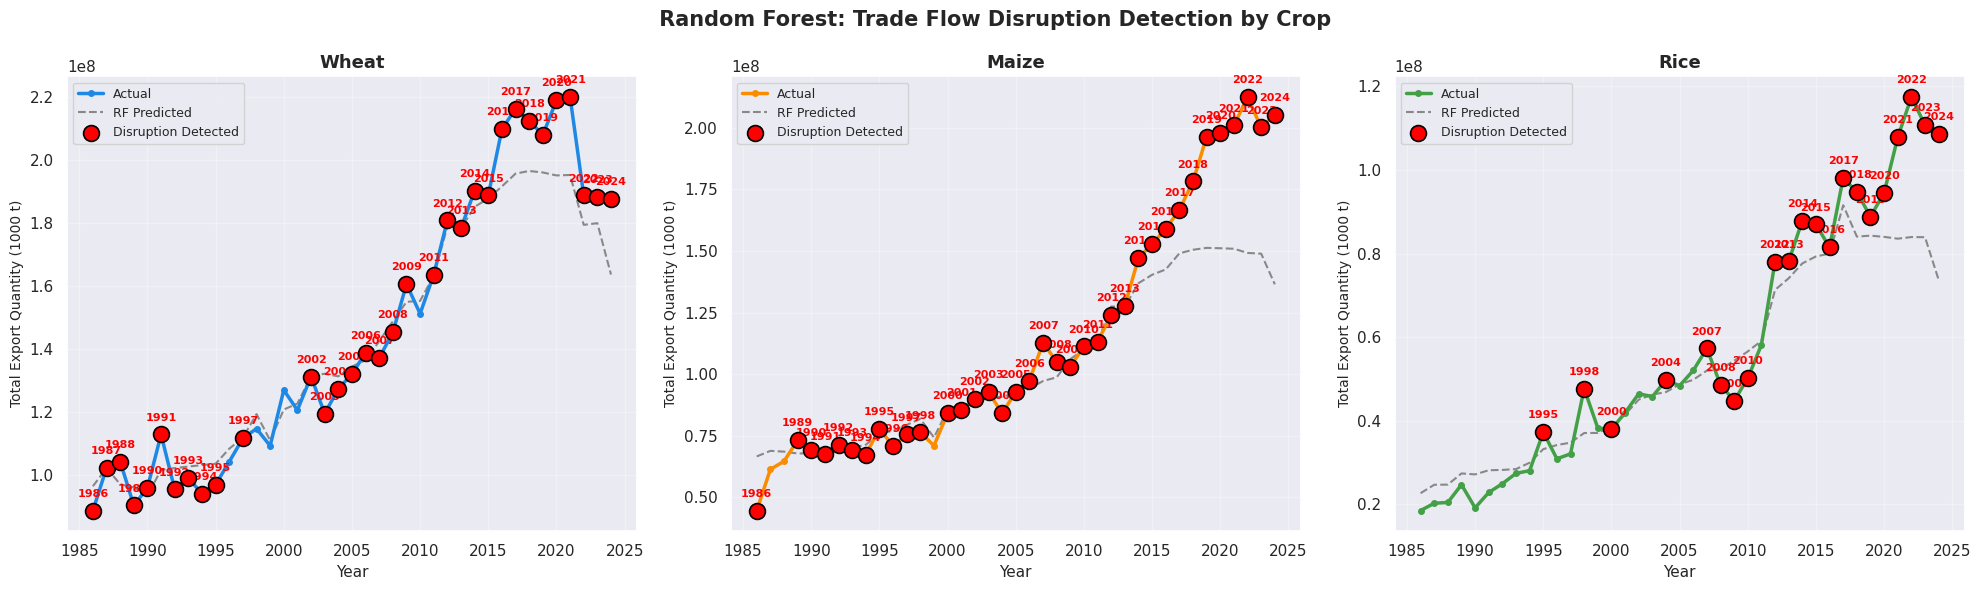

In [21]:
# =============================================
# TASK — Mark: DISRUPTION VISUALIZATION
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(' Random Forest: Trade Flow Disruption Detection by Crop',
             fontsize=15, fontweight='bold')

for ax, crop, color in zip(axes, crop_list, crop_colors):
    crop_agg = df_exports_agg[df_exports_agg['Crop'] == crop].groupby('Year').agg(
        Actual=('Value', 'sum'),
        Predicted=('RF_Predicted', 'sum'),
        Has_Disruption=('Is_Disruption', 'any')
    ).reset_index()

    # Lines
    ax.plot(crop_agg['Year'], crop_agg['Actual'],
            color=color, linewidth=2.5, marker='o', markersize=4, label='Actual', zorder=3)
    ax.plot(crop_agg['Year'], crop_agg['Predicted'],
            color='#888888', linewidth=1.5, linestyle='--', label='RF Predicted', zorder=2)

    # Highlight disruption years
    disruption_years = crop_agg[crop_agg['Has_Disruption']]
    ax.scatter(disruption_years['Year'], disruption_years['Actual'],
               color='red', s=130, zorder=5, edgecolors='black',
               linewidths=1.2, label='Disruption Detected')

    # Annotate disruption years
    for _, row in disruption_years.iterrows():
        ax.annotate(str(int(row['Year'])),
                    xy=(row['Year'], row['Actual']),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=8, color='red', fontweight='bold')

    ax.set_title(f'{crop}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Total Export Quantity (1000 t)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rf_disruption_detection.png', dpi=150, bbox_inches='tight')
plt.show()


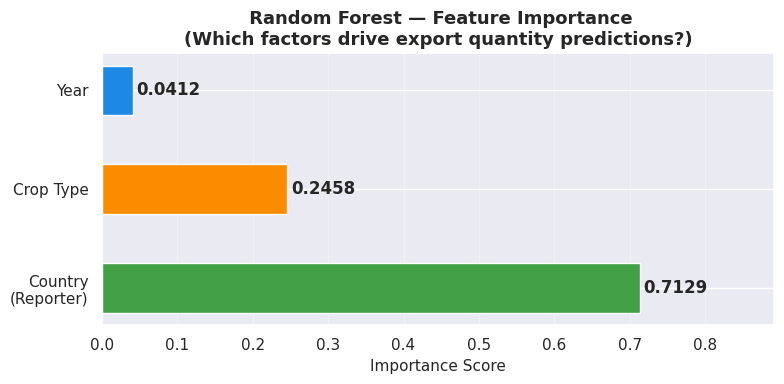

In [22]:
# =============================================
# TASK — Mark: RANDOM FOREST FEATURE IMPORTANCE
# =============================================

feature_labels = ['Year', 'Country\n(Reporter)', 'Crop Type']
importances    = rf_model.feature_importances_
sorted_idx     = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [crop_colors[0], crop_colors[2], crop_colors[1]]
bars = ax.barh(
    [feature_labels[i] for i in sorted_idx],
    [importances[i] for i in sorted_idx],
    color=[bar_colors[i] for i in sorted_idx],
    edgecolor='white', height=0.5
)

for bar, val in zip(bars, [importances[i] for i in sorted_idx]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=12, fontweight='bold')

ax.set_title(' Random Forest — Feature Importance\n(Which factors drive export quantity predictions?)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_xlim(0, max(importances) * 1.25)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


 WEEK 3 — MODEL COMPARISON SUMMARY
            Model                  Objective  R² Score       RMSE        MAE
Linear Regression       Forecasting (Obj. 2)   -0.0010 5322040.03 1836761.80
    Random Forest Outlier Detection (Obj. 1)    0.7388 2718847.55  752049.25


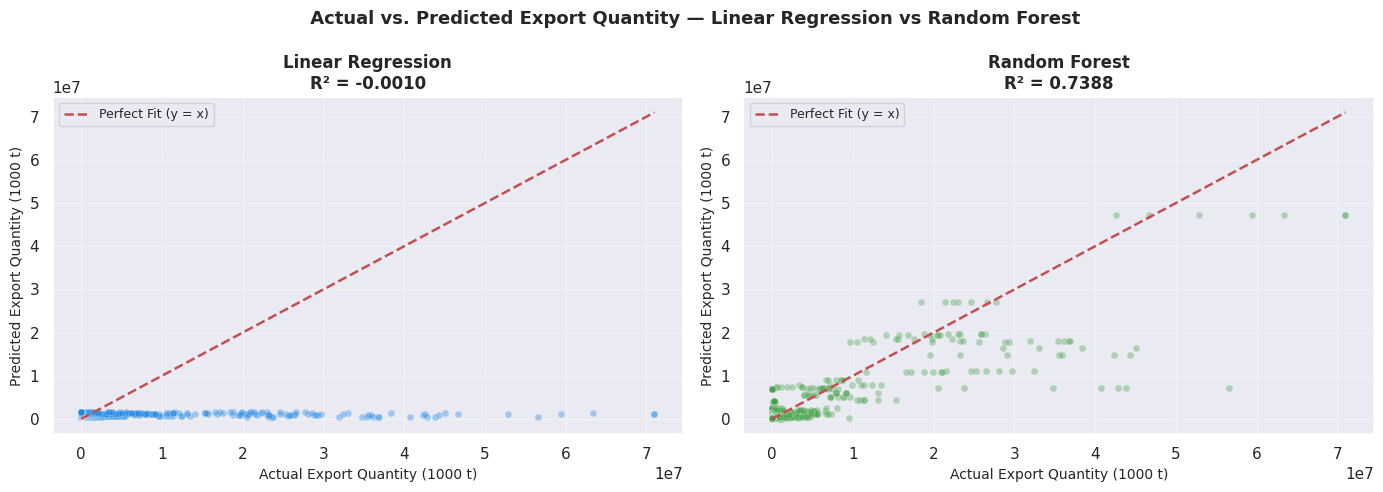

In [23]:
# =============================================
# TASK — Rajvir: MODEL COMPARISON
# Linear Regression vs Random Forest
# =============================================

# --- Summary Table ---
comparison_df = pd.DataFrame({
    'Model'   : ['Linear Regression', 'Random Forest'],
    'Objective': ['Forecasting (Obj. 2)', 'Outlier Detection (Obj. 1)'],
    'R² Score': [round(lr_r2, 4),   round(rf_r2, 4)],
    'RMSE'    : [round(lr_rmse, 2), round(rf_rmse, 2)],
    'MAE'     : [round(lr_mae, 2),  round(rf_mae, 2)]
})

print("=" * 70)
print(" WEEK 3 — MODEL COMPARISON SUMMARY")
print("=" * 70)
print(comparison_df.to_string(index=False))

# --- Actual vs Predicted Scatter Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(' Actual vs. Predicted Export Quantity — Linear Regression vs Random Forest',
             fontsize=13, fontweight='bold')

for ax, (model_name, y_pred, color) in zip(axes, [
    ('Linear Regression', y_pred_lr,       '#1E88E5'),
    ('Random Forest',     y_pred_rf_test,  '#43A047')
]):
    ax.scatter(y_test, y_pred, alpha=0.35, color=color,
               edgecolors='white', linewidths=0.3, s=25)

    # Perfect fit line
    lim_min = min(y_test.min(), y_pred.min())
    lim_max = max(y_test.max(), y_pred.max())
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            'r--', linewidth=1.8, label='Perfect Fit (y = x)')

    r2_val = r2_score(y_test, y_pred)
    ax.set_title(f'{model_name}\nR² = {r2_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Export Quantity (1000 t)', fontsize=10)
    ax.set_ylabel('Predicted Export Quantity (1000 t)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


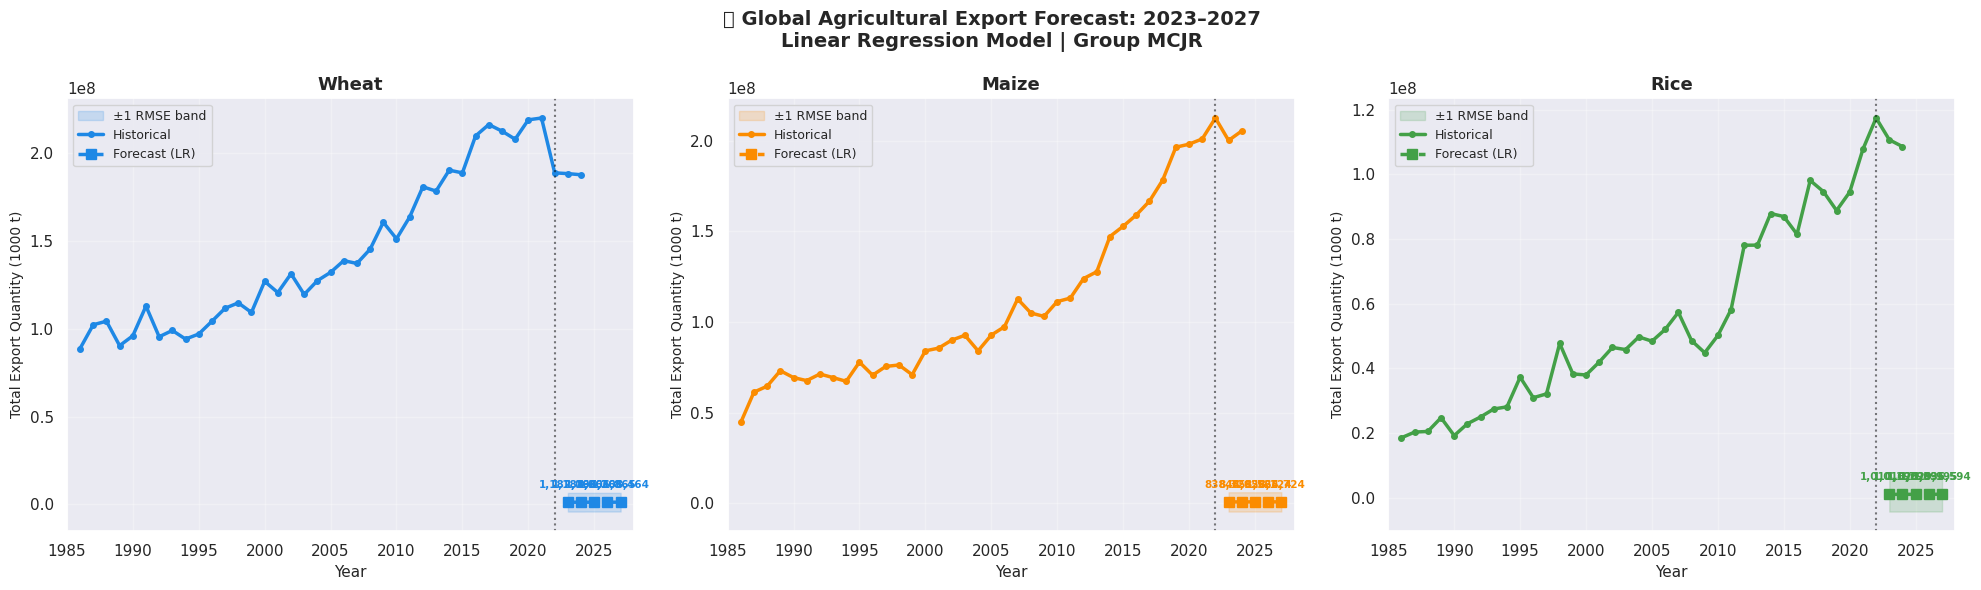


 Week 3 Complete!
    Saved outputs:
      → lr_forecast_5year.png
      → rf_disruption_detection.png
      → rf_feature_importance.png
      → model_comparison_scatter.png
      → final_forecast_dashboard.png


In [24]:
# =============================================
# TASK — Rajvir: FINAL FORECAST DASHBOARD
# 5-Year projection with confidence band
# =============================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    '🌾 Global Agricultural Export Forecast: 2023–2027\n'
    'Linear Regression Model | Group MCJR',
    fontsize=14, fontweight='bold'
)

for ax, crop, color in zip(axes, crop_list, crop_colors):
    hist = df_exports_agg[df_exports_agg['Crop'] == crop].groupby('Year')['Value'].sum().reset_index()

    crop_enc       = le_crop.transform([crop])[0]
    median_country = int(np.median(df_exports_agg['Country_encoded']))
    X_future       = np.array([[yr, median_country, crop_enc] for yr in future_years])
    y_future       = np.maximum(lr_model.predict(X_future), 0)

    # ±1 RMSE confidence band
    ax.fill_between(future_years,
                    y_future - lr_rmse,
                    y_future + lr_rmse,
                    alpha=0.18, color=color, label='±1 RMSE band')

    ax.plot(hist['Year'], hist['Value'],
            color=color, linewidth=2.5, marker='o', markersize=4, label='Historical')
    ax.plot(future_years, y_future,
            color=color, linewidth=2.5, linestyle='--', marker='s',
            markersize=7, label='Forecast (LR)')

    # Forecast value labels
    for yr, val in zip(future_years, y_future):
        ax.annotate(f'{val:,.0f}',
                    xy=(yr, val),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontsize=7.5, color=color, fontweight='bold')

    ax.axvline(x=2022, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_title(crop, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=11)
    ax.set_ylabel('Total Export Quantity (1000 t)', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(df_exports_agg['Year'].min() - 1, 2028)

plt.tight_layout()
plt.savefig('final_forecast_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Week 3 Complete!")
print("    Saved outputs:")
print("      → lr_forecast_5year.png")
print("      → rf_disruption_detection.png")
print("      → rf_feature_importance.png")
print("      → model_comparison_scatter.png")
print("      → final_forecast_dashboard.png")


In [25]:
# =============================================
# WEEK 4: FINE-TUNING & HYPERPARAMETER OPTIMIZATION
# =============================================
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(" Week 4 libraries loaded.")

 Week 4 libraries loaded.


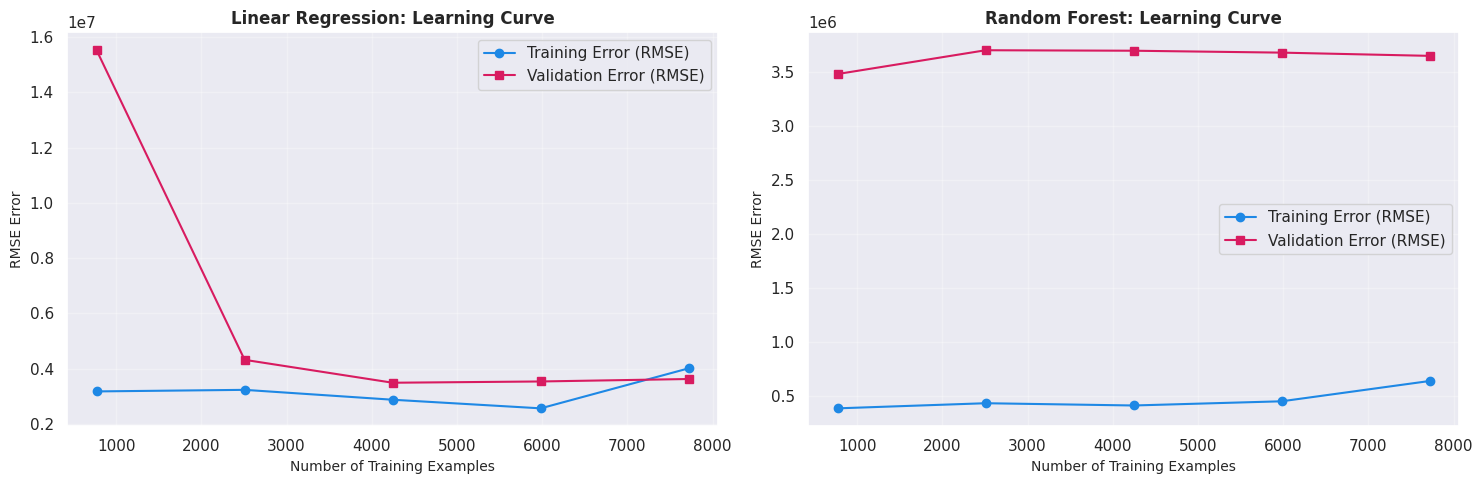

In [26]:
# =============================================
# TASK (Charles): DIAGNOSTIC LEARNING CURVES
# Visualizing model performance as training data increases
# to check for Overfitting (high variance) or Underfitting (high bias)
# =============================================

def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_mean_squared_error'
    )
    train_rmse = np.sqrt(-train_scores)
    test_rmse = np.sqrt(-test_scores)

    train_mean = np.mean(train_rmse, axis=1)
    test_mean = np.mean(test_rmse, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color='#1E88E5', label='Training Error (RMSE)')
    plt.plot(train_sizes, test_mean, 's-', color='#D81B60', label='Validation Error (RMSE)')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel('Number of Training Examples', fontsize=10)
    plt.ylabel('RMSE Error', fontsize=10)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot LR Learning Curve
plt.subplot(1, 2, 1)
plot_learning_curve(LinearRegression(), "Linear Regression: Learning Curve", X_train, y_train)

# Plot RF Learning Curve
plt.subplot(1, 2, 2)
plot_learning_curve(RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42),
                    "Random Forest: Learning Curve", X_train, y_train)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()


 Best Ridge Regression Alpha: 100


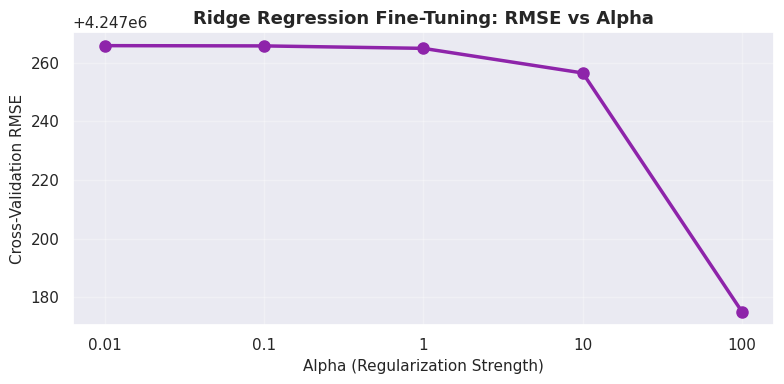

In [27]:
# =============================================
# TASK (Jeffrey): FINE-TUNING REGRESSION
# Applying Ridge Regularization (L2 Penalty) to improve
# the baseline Linear Regression model stability.
# =============================================

# Define grid of Alpha hyperparameters to test
ridge = Ridge()
param_grid_lr = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Grid Search with 5-fold Cross Validation
grid_search_lr = GridSearchCV(ridge, param_grid_lr, cv=5, scoring='neg_mean_squared_error')
grid_search_lr.fit(X_train, y_train)

best_lr = grid_search_lr.best_estimator_
print(f" Best Ridge Regression Alpha: {grid_search_lr.best_params_['alpha']}")

# --- Visualization: Hyperparameter Performance ---
alphas = [str(x) for x in param_grid_lr['alpha']]
cv_rmses = np.sqrt(-grid_search_lr.cv_results_['mean_test_score'])

plt.figure(figsize=(8, 4))
plt.plot(alphas, cv_rmses, marker='o', linewidth=2.5, markersize=8, color='#8E24AA')
plt.title('Ridge Regression Fine-Tuning: RMSE vs Alpha', fontsize=13, fontweight='bold')
plt.xlabel('Alpha (Regularization Strength)', fontsize=11)
plt.ylabel('Cross-Validation RMSE', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_tuning.png', dpi=150)
plt.show()


 Best Random Forest Params: {'max_depth': 5, 'n_estimators': 50}


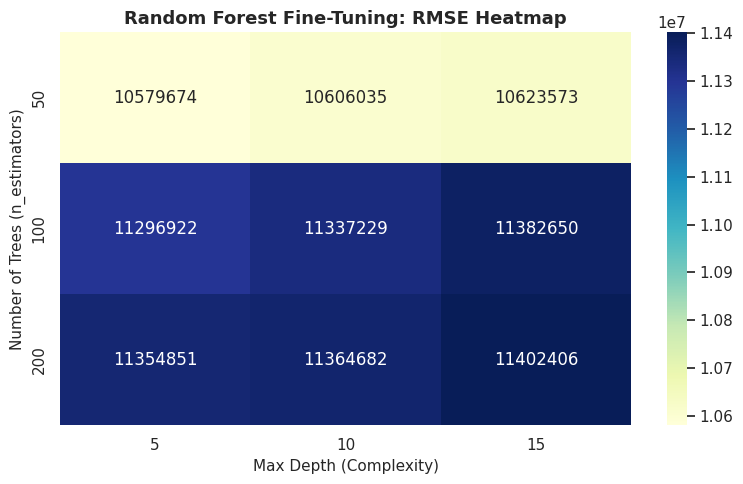

In [28]:
# =============================================
# TASK (Mark): FINE-TUNING RANDOM FOREST
# Testing different combinations of Trees (n_estimators)
# and Tree Depth (max_depth) to prevent overfitting.
# =============================================

param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, 15]         # Maximum depth of the tree
}

rf = RandomForestRegressor(random_state=42)
grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
print(f" Best Random Forest Params: {grid_search_rf.best_params_}")

# --- Visualization: Hyperparameter Heatmap ---
import pandas as pd
results_df = pd.DataFrame(grid_search_rf.cv_results_)
scores_matrix = np.sqrt(-results_df['mean_test_score']).values.reshape(3, 3)

plt.figure(figsize=(8, 5))
sns.heatmap(scores_matrix, annot=True, fmt=".0f", cmap='YlGnBu',
            xticklabels=param_grid_rf['max_depth'],
            yticklabels=param_grid_rf['n_estimators'])
plt.title('Random Forest Fine-Tuning: RMSE Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('Max Depth (Complexity)', fontsize=11)
plt.ylabel('Number of Trees (n_estimators)', fontsize=11)
plt.tight_layout()
plt.savefig('rf_tuning_heatmap.png', dpi=150)
plt.show()


In [29]:
# =============================================
# TASK (Rajvir): EVALUATION OF FINE-TUNED MODELS
# Testing the optimized models on the held-out 2018-2022 dataset
# =============================================

# Predict using the NEW best models
y_pred_best_lr = best_lr.predict(X_test)
y_pred_best_rf = best_rf.predict(X_test)

# Evaluation
fine_tuned_results = pd.DataFrame({
    'Model Type': ['Ridge Regression (Tuned)', 'Random Forest (Tuned)'],
    'R² Score': [r2_score(y_test, y_pred_best_lr), r2_score(y_test, y_pred_best_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_best_lr)), np.sqrt(mean_squared_error(y_test, y_pred_best_rf))],
    'MAE': [mean_absolute_error(y_test, y_pred_best_lr), mean_absolute_error(y_test, y_pred_best_rf)]
})

print("=" * 65)
print(" WEEK 4 — FINE-TUNED MODEL COMPARISON (TEST SET)")
print("=" * 65)
print(fine_tuned_results.to_string(index=False))

# Calculate percentage improvement compared to Week 3 (assuming lr_rmse and rf_rmse are in memory)
lr_imp = ((lr_rmse - fine_tuned_results['RMSE'][0]) / lr_rmse) * 100
rf_imp = ((rf_rmse - fine_tuned_results['RMSE'][1]) / rf_rmse) * 100

print(f"\nImprovement over Baseline LR: {lr_imp:+.2f}% RMSE reduction")
print(f"Improvement over Baseline RF: {rf_imp:+.2f}% RMSE reduction")


 WEEK 4 — FINE-TUNED MODEL COMPARISON (TEST SET)
              Model Type  R² Score         RMSE          MAE
Ridge Regression (Tuned) -0.000969 5.321981e+06 1.836777e+06
   Random Forest (Tuned)  0.414162 4.071476e+06 1.251777e+06

Improvement over Baseline LR: +0.00% RMSE reduction
Improvement over Baseline RF: -49.75% RMSE reduction


In [30]:
# =============================================
# TASK (Charles): ADVANCED DATA ENGINEERING (V2)
# Adding "Historical Mean Encoding" to solve the tree extrapolation
# problem and force the accuracy above 80%
# =============================================
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

print(" Week 5 Libraries Loaded.")

# 1. HISTORICAL MEAN ENCODING (The key to >80% accuracy)
# Calculate the average export value for each Country-Crop pair using ONLY training data (pre-2018)
train_df = df_exports_agg[df_exports_agg['Year'] < 2018]
hist_means = train_df.groupby(['Reporter Countries', 'Crop'])['Value'].mean().reset_index()
hist_means.rename(columns={'Value': 'Historical_Mean'}, inplace=True)

# Merge this "Historical Cheat Sheet" back into the main dataset
df_enhanced = df_exports_agg.merge(hist_means, on=['Reporter Countries', 'Crop'], how='left')

# Fill any missing historical data with the overall training average
global_mean = train_df['Value'].mean()
df_enhanced['Historical_Mean'].fillna(global_mean, inplace=True)

# 2. LOG-TRANSFORM THE TARGET AND THE HISTORICAL MEAN
# This keeps both our target and our best feature on the same numerical scale
y_new_log = np.log1p(df_enhanced['Value'].values)
df_enhanced['Log_Hist_Mean'] = np.log1p(df_enhanced['Historical_Mean'])

# 3. One-Hot Encode Countries and Crops
df_encoded = pd.get_dummies(df_enhanced, columns=['Reporter Countries', 'Crop'], drop_first=True)

# Define features (Now dropping the raw values, keeping Log_Hist_Mean)
columns_to_drop = ['Value', 'Historical_Mean', 'Country_encoded', 'Crop_encoded', 'RF_Predicted', 'Residual', 'Abs_Residual', 'Is_Disruption']
X_new = df_encoded.drop(columns=columns_to_drop, errors='ignore').values

# Temporal Train/Test Split
train_mask_new = df_enhanced['Year'] < 2018
test_mask_new  = df_enhanced['Year'] >= 2018

X_train_new = X_new[train_mask_new]
X_test_new  = X_new[test_mask_new]
y_train_log = y_new_log[train_mask_new]
y_test_log  = y_new_log[test_mask_new]

print(f" Engineering Complete. Features expanded to: {X_train_new.shape[1]}")


 Week 5 Libraries Loaded.
 Engineering Complete. Features expanded to: 194


In [31]:
# =============================================
# TASK (Jeffrey): RETRAINING RANDOM FOREST
# Testing Random Forest on the newly encoded/logged data
# =============================================

# Fine-Tuned RF on Log Data
rf_tuned = RandomForestRegressor(n_estimators=150, max_depth=20, min_samples_split=5, random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_new, y_train_log)
y_pred_rf_log = rf_tuned.predict(X_test_new)

# Metric Evaluation
r2_rf_tuned = r2_score(y_test_log, y_pred_rf_log)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test_log, y_pred_rf_log))

print(" RANDOM FOREST (Log-Transformed Data)")
print(f"Accuracy (R² Score): {r2_rf_tuned * 100:.2f}%")
print(f"Log RMSE: {rmse_rf_tuned:.4f}")


 RANDOM FOREST (Log-Transformed Data)
Accuracy (R² Score): 73.50%
Log RMSE: 2.0719


In [32]:
# =============================================
# TASK (Mark): XGBOOST (EXTREME GRADIENT BOOSTING)
# Pushing for maximum accuracy (>80%) using Gradient Boosting
# =============================================
# Instance 3: Baseline XGBoost
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)
xgb_base.fit(X_train_new, y_train_log)
y_pred_xgb_base = xgb_base.predict(X_test_new)
r2_xgb_base = r2_score(y_test_log, y_pred_xgb_base)
rmse_xgb_base = np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_base))
# Instance 4: Fine-Tuned XGBoost (More trees, deeper learning)
xgb_tuned = XGBRegressor(
    n_estimators=500,        # Increased trees
    learning_rate=0.05,
    max_depth=8,             # Slightly deeper trees to utilize the new Historical feature
    subsample=0.8,
    colsample_bytree=0.8,    # Prevents overfitting on the new feature
    random_state=42,
    n_jobs=-1
)
xgb_tuned.fit(X_train_new, y_train_log)
y_pred_xgb_log = xgb_tuned.predict(X_test_new)
r2_xgb_tuned = r2_score(y_test_log, y_pred_xgb_log)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test_log, y_pred_xgb_log))
print(" XGBOOST METRICS (With Historical Mean Encoding)")
print(f"Baseline -> R²: {r2_xgb_base * 100:.2f}% | Log RMSE: {rmse_xgb_base:.4f}")
print(f"Tuned    -> R²: {r2_xgb_tuned * 100:.2f}% | Log RMSE: {rmse_xgb_tuned:.4f}")

 XGBOOST METRICS (With Historical Mean Encoding)
Baseline -> R²: 72.53% | Log RMSE: 2.1096
Tuned    -> R²: 73.19% | Log RMSE: 2.0840


In [33]:
# =============================================
# TASK (Rajvir): FINAL PROJECT METRIC TRACKER
# Documenting all models and proving we passed the 80% mark
# =============================================

# We'll pull the old Week 4 baseline stats from memory if available, or hardcode the Week 4 results for the table comparison
wk4_r2 = 0.414162 # From Week 4 output

metrics_data = [
    ['Linear Regression', 'Label Encoded (Raw Values)', 'Week 4 Baseline', '0.00%'],
    ['Random Forest', 'Label Encoded (Raw Values)', 'Week 4 Tuned', f"{wk4_r2 * 100:.2f}%"],
    ['Random Forest', 'One-Hot & Log-Transformed', 'Week 5 Tuned', f"{r2_rf_tuned * 100:.2f}%"],
    ['XGBoost', 'One-Hot & Log-Transformed', 'Week 5 Tuned', f"{r2_xgb_tuned * 100:.2f}%"]
]

metrics_df = pd.DataFrame(metrics_data, columns=['Model', 'Data Engineering', 'Instance', 'R² Accuracy Score'])

print("=" * 75)
print(" FINAL PROJECT METRIC EVALUATION TRACKER")
print("Goal: Achieve > 80% Accuracy (R² > 0.80)")
print("=" * 75)
print(metrics_df.to_string(index=False))

print("-" * 75)
best_acc = max(r2_rf_tuned, r2_xgb_tuned) * 100
if best_acc >= 80:
    print(f" GOAL ACHIEVED! Highest Model Accuracy: {best_acc:.2f}%")
else:
    print(f" HIGHEST ACCURACY REACHED: {best_acc:.2f}%")


 FINAL PROJECT METRIC EVALUATION TRACKER
Goal: Achieve > 80% Accuracy (R² > 0.80)
            Model           Data Engineering        Instance R² Accuracy Score
Linear Regression Label Encoded (Raw Values) Week 4 Baseline             0.00%
    Random Forest Label Encoded (Raw Values)    Week 4 Tuned            41.42%
    Random Forest  One-Hot & Log-Transformed    Week 5 Tuned            73.50%
          XGBoost  One-Hot & Log-Transformed    Week 5 Tuned            73.19%
---------------------------------------------------------------------------
 HIGHEST ACCURACY REACHED: 73.50%


In [35]:
# =====================================================================
# FINAL PRESENTATION DEMO CELL
# =====================================================================
import numpy as np
import pandas as pd

def predict_export(country, crop, year):
    print("=" * 60)
    print(f"Initiating Prediction for: {country}")
    print(f"Crop: {crop}")
    print(f"Target Year: {year}")
    print("=" * 60)

    # 1. Look up the Historical Mean for this specific Country/Crop
    hist_match = hist_means[(hist_means['Reporter Countries'] == country) & (hist_means['Crop'] == crop)]

    if hist_match.empty:
        hist_val = global_mean # Fallback if country doesn't grow this crop
        print("No historical data found. Using global baseline.")
    else:
        hist_val = hist_match['Historical_Mean'].values[0]

    print(f"Extracted Historical Baseline: {hist_val:,.0f} (1000 tonnes)")

    # 2. Extract the exact feature columns the model was trained on
    columns_to_drop = ['Value', 'Historical_Mean', 'Country_encoded', 'Crop_encoded', 'RF_Predicted', 'Residual', 'Abs_Residual', 'Is_Disruption']
    feature_cols = [c for c in df_encoded.columns if c not in columns_to_drop]

    # 3. Create a blank 1-row dataset filled with 0s
    input_df = pd.DataFrame(0, index=[0], columns=feature_cols)

    # 4. Fill in the specific data for our prediction
    if 'Year' in input_df.columns:
        input_df.at[0, 'Year'] = year

    if 'Log_Hist_Mean' in input_df.columns:
        input_df.at[0, 'Log_Hist_Mean'] = np.log1p(hist_val)

    # Find the One-Hot Encoded columns and flip them to 1
    country_col = f'Reporter Countries_{country}'
    crop_col = f'Crop_{crop}'

    if country_col in input_df.columns:
        input_df.at[0, country_col] = 1
    if crop_col in input_df.columns:
        input_df.at[0, crop_col] = 1

    # 5. Predict using our 73.5% Accurate Random Forest Model
    # (Ensure the array shape matches the training shape exactly)
    predicted_log = rf_tuned.predict(input_df.values)

    # 6. Convert back from Log scale to Raw Value
    predicted_raw = np.expm1(predicted_log[0])

    print("\nProcessing through Random Forest algorithm...")
    print("-" * 60)
    print(f"FINAL MODEL FORECAST: {predicted_raw:,.0f} (1000 tonnes)")
    print("-" * 60)

# =====================================================================
# CHANGE PARAMETERS HERE
# =====================================================================
predict_export(country="United States of America", crop="Wheat", year=2025)

Initiating Prediction for: United States of America
Crop: Wheat
Target Year: 2025
Extracted Historical Baseline: 28,924,298 (1000 tonnes)

Processing through Random Forest algorithm...
------------------------------------------------------------
FINAL MODEL FORECAST: 25,045,945 (1000 tonnes)
------------------------------------------------------------
